In [45]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm, ListedColormap

In [46]:
# File path to Dynamic World LULC data
root_directory = Path.cwd().parent
geotif_folder_path = root_directory / "data" / "raw" / "custom_aoi_LULC" 
geotif_folder = [file_path for file_path in geotif_folder_path.glob("*.tif")]

# Load the AOI used to clip the Dynamic World rasters
aoi_path = root_directory / "data" / "raw" / "custom_aoi_geojson" / "custom_aoi.geojson"
aoi = gpd.read_file(aoi_path)

In [47]:
# Validate data coordinate reference system, shape, resolution, bounds etc
for geotif_file_path in geotif_folder:
    with rasterio.open(geotif_file_path) as geotif_file:
        print(f"------  {geotif_file.name.rsplit(sep="/")[-1]} ---------")
        print(f"CRS: {geotif_file.crs}")
        print(f"Shape: {geotif_file.height} rows × {geotif_file.width} columns")
        print(f"Resolution: {geotif_file.res}")
        print(f"Bounds: {geotif_file.bounds}")
        print(f"Band count: {geotif_file.count}")
        print(f"Data type: {geotif_file.dtypes}")
        print(f"NoData: {geotif_file.nodata}")

------  lulc_2025_jan_feb.tif ---------
CRS: EPSG:4326
Shape: 950 rows × 1053 columns
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=5.638725038418237, bottom=6.368875701350584, right=5.733317637836022, top=6.454215653341938)
Band count: 1
Data type: ('uint8',)
NoData: 255.0
------  lulc_2020_jan_feb.tif ---------
CRS: EPSG:4326
Shape: 950 rows × 1053 columns
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=5.638725038418237, bottom=6.368875701350584, right=5.733317637836022, top=6.454215653341938)
Band count: 1
Data type: ('uint8',)
NoData: 255.0
------  lulc_2016_jan_feb.tif ---------
CRS: EPSG:4326
Shape: 950 rows × 1053 columns
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds: BoundingBox(left=5.638725038418237, bottom=6.368875701350584, right=5.733317637836022, top=6.454215653341938)
Band count: 1
Data type: ('uint8',)
NoData: 255.0


In [48]:
# Extract and display the class values in each geotif file
dict_ = {}

for geotif_file_path in geotif_folder:
    with rasterio.open(geotif_file_path) as geotif_file:
        data = geotif_file.read(1, masked=True)

        class_, class_count = np.unique(
            data.compressed(),
            return_counts=True
        )
        dict_[str(geotif_file_path.name.rsplit(sep="/")[-1])] = dict(zip(class_, class_count))

df = pd.DataFrame(data=dict_).reset_index().rename(columns={"index":"classes"})

# display df
df

,classes,lulc_2025_jan_feb.tif,lulc_2020_jan_feb.tif,lulc_2016_jan_feb.tif
0,0,232.0,322,738
1,1,119004.0,252006,314203
2,2,534.0,47,783
3,4,2388.0,23674,3483
4,5,94337.0,45527,39188
5,6,368448.0,256573,224004
6,3,NaN,216,446
7,7,NaN,6578,2098


In [49]:
# class_label are Dynamic World classes. Create a column displaying their meanings
CLASS_NAMES = {
    0: "Water",
    1: "Trees",
    2: "Grass",
    3: "Flooded vegetation",
    4: "Crops",
    5: "Shrub and scrub",
    6: "Built area",
    7: "Bare ground",
    8: "Snow and ice",
}         # class_label and their meaning

# Create a new column displaying classes meaning
df["class_label"] = df['classes'].map(CLASS_NAMES)

# Re-arrange DataFrame column placement
df = df[["classes", "class_label", "lulc_2016_jan_feb.tif", "lulc_2020_jan_feb.tif", "lulc_2025_jan_feb.tif"]]

# Display DataFrame
df

,classes,class_label,lulc_2016_jan_feb.tif,lulc_2020_jan_feb.tif,lulc_2025_jan_feb.tif
0,0,Water,738,322,232.0
1,1,Trees,314203,252006,119004.0
2,2,Grass,783,47,534.0
3,4,Crops,3483,23674,2388.0
4,5,Shrub and scrub,39188,45527,94337.0
5,6,Built area,224004,256573,368448.0
6,3,Flooded vegetation,446,216,NaN
7,7,Bare ground,2098,6578,NaN


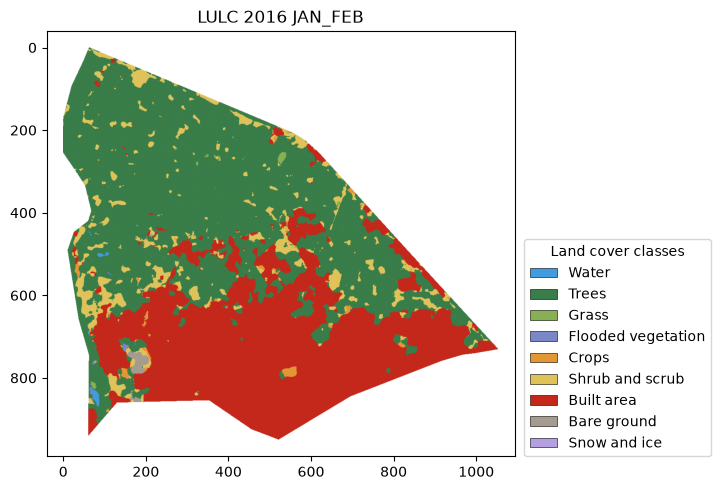

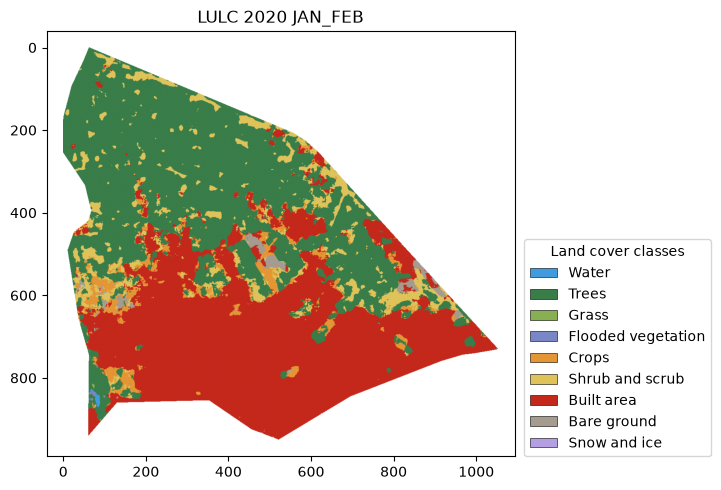

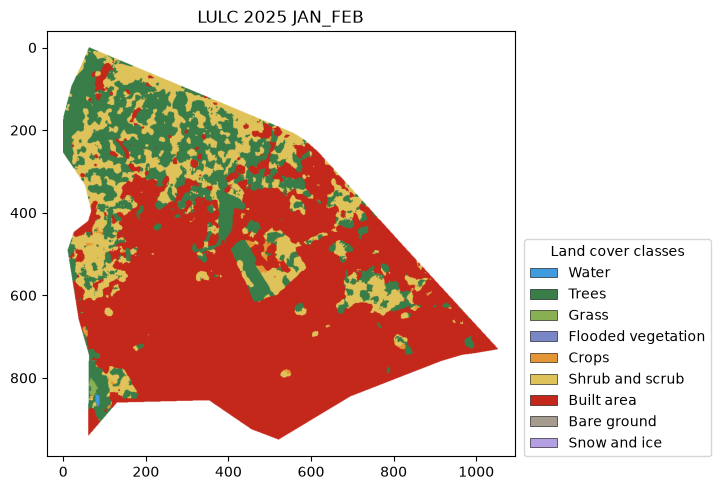

In [50]:
class_colors = [
    "#419BDF",  # Water
    "#397D49",  # Trees
    "#88B053",  # Grass
    "#7A87C6",  # Flooded vegetation
    "#E49635",  # Crops
    "#DFC35A",  # Shrub and scrub
    "#C4281B",  # Built area
    "#A59B8F",  # Bare ground
    "#B39FE1",  # Snow and ice
]

cmap = ListedColormap(class_colors)

norm = BoundaryNorm(
    boundaries=np.arange(-0.5, 9.5, 1),
    ncolors=cmap.N,
)

legend_handles = [
    Patch(
        facecolor=class_colors[class_value],
        edgecolor="black",
        linewidth=0.4,
        label=class_name,
    )
    for class_value, class_name in CLASS_NAMES.items()
]

for geotif_file_path in reversed(geotif_folder):
    with rasterio.open(geotif_file_path) as geotif_file:
        data = geotif_file.read(1, masked=True)

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.imshow(data, cmap=cmap, norm=norm)

    # pad the plot to prevent part of the figure from being cuttoff by the axis
    height, width = data.shape
    pad = 40
    ax.set_xlim(-pad, width+pad)
    ax.set_ylim(height+pad, -pad)

    ax.set_title(geotif_file_path.stem.replace("_", " ", count=2).upper())
   
    ax.legend(
        handles=legend_handles,
        title="Land cover classes",
        loc="lower left",
        bbox_to_anchor=(1.02, 0),
        borderaxespad=0,
        frameon=True
    )

    plt.tight_layout()
    plt.show()